# GeoFlare — Notebook 01: FIRMS Data Exploration

**Goal:** Get real NASA FIRMS thermal-anomaly data into GeoFlare, clean it, understand it, and create our first geographic visualization.

### This notebook covers
1. Loading configuration
2. Downloading recent FIRMS data for India
3. Cleaning and validating the dataset
4. Understanding important FIRMS fields
5. Summary statistics
6. Temporal patterns
7. A first India-focused map
8. Saving cleaned data for the next phase

> **Important:** Never put your FIRMS MAP_KEY directly into the notebook. Store it in `.env`.

## 0. Where this notebook fits

```text
NASA FIRMS
    ↓
THIS NOTEBOOK: Ingest → Clean → Explore → Visualize
    ↓
Historical baseline
    ↓
OSM geospatial context
    ↓
Feature engineering
    ↓
XGBoost classification
    ↓
SHAP explanations
    ↓
Risk scoring
    ↓
Dashboard
```

First milestone:

**Real FIRMS data → clean data → understand data → map data**

In [1]:
# Install once if needed:
# %pip install pandas numpy matplotlib requests python-dotenv

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv

print("Imports successful.")

Imports successful.


In [ ]:
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DIR)
print("Processed data:", PROCESSED_DIR)

## 1. Configure NASA FIRMS

Create `GeoFlare/.env`:

```text
FIRMS_MAP_KEY=YOUR_KEY_HERE
```

Keep the key outside the notebook so it does not get committed to GitHub.

In [7]:
from pathlib import Path
import os
from dotenv import load_dotenv

# Find the ThermoTech project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Load the .env file from the project root
env_path = PROJECT_ROOT / "backend" / ".env"
load_dotenv(env_path)

FIRMS_MAP_KEY = os.getenv("FIRMS_MAP_KEY")

if FIRMS_MAP_KEY:
    print("FIRMS MAP_KEY loaded successfully.")
else:
    print("WARNING: FIRMS_MAP_KEY not found.")
    print(f"Expected .env location: {env_path}")

FIRMS MAP_KEY loaded successfully.


## 2. Download recent FIRMS data

For the first run:
- **Region:** India
- **Source:** VIIRS
- **Window:** last 7 days
- **Format:** CSV

We intentionally start small before working with larger historical datasets.

In [13]:
FIRMS_SOURCE = "VIIRS_SNPP_NRT"
AREA = "68,6,97,37"
DAYS = 3

url = (
    f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
    f"{FIRMS_MAP_KEY}/{FIRMS_SOURCE}/{AREA}/{DAYS}"
)

print("Source:", FIRMS_SOURCE)
print("Area:", AREA)
print("Days:", DAYS)

Source: VIIRS_SNPP_NRT
Area: 68,6,97,37
Days: 3


In [14]:
# Set up project directories

PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DIR)

Project root: c:\Users\ASUS\Documents\Sidra\ThermoTech
Raw data folder: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\raw


In [15]:
raw_file = RAW_DIR / f"firms_{FIRMS_SOURCE.lower()}_{AREA.lower()}_{DAYS}d.csv"

if not FIRMS_MAP_KEY:
    raise ValueError("FIRMS_MAP_KEY is missing. Add it to ThermoTech/.env.")

response = requests.get(url, timeout=60)
response.raise_for_status()
raw_file.write_bytes(response.content)

print(f"Downloaded: {raw_file}")
print(f"Size: {raw_file.stat().st_size / 1024:.1f} KB")

Downloaded: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\raw\firms_viirs_snpp_nrt_68,6,97,37_3d.csv
Size: 87.0 KB


In [16]:
df = pd.read_csv(raw_file)

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

Rows: 1112
Columns: 14


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,27.95755,96.95478,334.77,0.44,0.38,2026-09-05,637,N,VIIRS,n,2.0NRT,285.13,5.26,D
1,27.95821,96.95849,328.12,0.44,0.38,2026-09-05,637,N,VIIRS,n,2.0NRT,284.71,5.26,D
2,6.17996,81.00569,341.03,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,302.13,2.48,D
3,6.18050,81.00926,337.19,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,301.79,2.48,D
4,6.18250,81.15936,336.90,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,302.46,3.84,D


## 3. Understand the FIRMS fields

Important fields for GeoFlare include:

| Field | Why we care |
|---|---|
| `latitude`, `longitude` | Location |
| `acq_date`, `acq_time` | Detection time |
| `frp` | Thermal intensity indicator |
| `confidence` | Detection confidence |
| `bright_ti4` | VIIRS thermal/brightness measurement |
| `bright_ti5` | Background thermal measurement |
| `satellite` | Source satellite |
| `instrument` | Sensor |
| `daynight` | Day/night detection |
| `scan`, `track` | Pixel footprint-related information |

**Do not build the ML model yet.** First understand the data.

In [17]:
print("Column names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

print("\nData types:")
display(df.dtypes)

Column names:
 1. latitude
 2. longitude
 3. bright_ti4
 4. scan
 5. track
 6. acq_date
 7. acq_time
 8. satellite
 9. instrument
10. confidence
11. version
12. bright_ti5
13. frp
14. daynight

Data types:


latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date          str
acq_time        int64
satellite         str
instrument        str
confidence        str
version           str
bright_ti5    float64
frp           float64
daynight          str
dtype: object

In [18]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing)

,missing_count,missing_percent
latitude,0,0.0
longitude,0,0.0
bright_ti4,0,0.0
scan,0,0.0
track,0,0.0
acq_date,0,0.0
acq_time,0,0.0
satellite,0,0.0
instrument,0,0.0
confidence,0,0.0


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 4. Clean the core fields

We will:
- convert acquisition date/time into a timestamp,
- convert important numeric fields,
- remove rows without valid coordinates,
- preserve unusual FRP/confidence values for investigation later.

We do **not** aggressively filter anomalies yet.

In [22]:
fires = df.copy()

numeric_cols = [
    "latitude", "longitude", "frp",
    "bright_ti4", "bright_ti5", "scan", "track"
]

for col in numeric_cols:
    if col in fires.columns:
        fires[col] = pd.to_numeric(fires[col], errors="coerce")

if "acq_date" in fires.columns:
    fires["acq_date"] = pd.to_datetime(fires["acq_date"], errors="coerce")

if "acq_time" in fires.columns:
    time_str = (
        fires["acq_time"].astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(4)
    )
    fires["acq_time_clean"] = time_str.str[:4]

if {"acq_date", "acq_time_clean"}.issubset(fires.columns):
    fires["acq_datetime"] = pd.to_datetime(
        fires["acq_date"].dt.strftime("%Y-%m-%d") + " " +
        fires["acq_time_clean"].str[:2] + ":" +
        fires["acq_time_clean"].str[2:4],
        errors="coerce"
    )

if {"latitude", "longitude"}.issubset(fires.columns):
    fires = fires[
        fires["latitude"].between(-90, 90) &
        fires["longitude"].between(-180, 180)
    ].copy()

print("Cleaned rows:", len(fires))
display(fires.head())

Cleaned rows: 1112


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,acq_time_clean,acq_datetime
0,27.95755,96.95478,334.77,0.44,0.38,2026-09-05,637,N,VIIRS,n,2.0NRT,285.13,5.26,D,0637,2026-09-05 06:37:00
1,27.95821,96.95849,328.12,0.44,0.38,2026-09-05,637,N,VIIRS,n,2.0NRT,284.71,5.26,D,0637,2026-09-05 06:37:00
2,6.17996,81.00569,341.03,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,302.13,2.48,D,0813,2026-09-05 08:13:00
3,6.18050,81.00926,337.19,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,301.79,2.48,D,0813,2026-09-05 08:13:00
4,6.18250,81.15936,336.90,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,302.46,3.84,D,0813,2026-09-05 08:13:00


In [23]:
print("Missing values after cleaning:")
display(fires.isna().sum())

print("\nConfidence values:")
print(fires["confidence"].value_counts(dropna=False))

Missing values after cleaning:


latitude          0
longitude         0
bright_ti4        0
scan              0
track             0
acq_date          0
acq_time          0
satellite         0
instrument        0
confidence        0
version           0
bright_ti5        0
frp               0
daynight          0
acq_time_clean    0
acq_datetime      0
dtype: int64


Confidence values:
confidence
n    979
l    128
h      5
Name: count, dtype: int64


In [24]:
# Save cleaned FIRMS data

clean_path = PROCESSED_DIR / "firms_india_viirs_clean.csv"

fires.to_csv(clean_path, index=False)

print(f"Cleaned data saved to: {clean_path}")
print(f"Rows saved: {len(fires):,}")

Cleaned data saved to: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\processed\firms_india_viirs_clean.csv
Rows saved: 1,112


## 5. Statistical profile

Pay particular attention to **FRP**.

Later, ThermoTech will use not only absolute FRP, but also whether FRP is unusual relative to a location's historical baseline.

In [25]:
summary_cols = [
    c for c in [
        "latitude", "longitude", "frp", "confidence",
        "bright_ti4", "bright_ti5", "scan", "track"
    ] if c in fires.columns
]

display(fires[summary_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
latitude,1112.0,14.293778,7.173129,6.13792,8.173652,10.99535,20.970188,36.97208
longitude,1112.0,81.230660,3.929719,68.37363,80.101075,80.83806,82.169295,96.97713
frp,1112.0,4.973813,5.098556,0.27000,2.127500,3.92000,6.262500,78.55000
bright_ti4,1112.0,329.344739,14.568122,295.28000,314.977500,333.96500,339.200000,367.00000
bright_ti5,1112.0,296.372527,7.326546,258.38000,291.110000,298.09000,302.170000,311.54000
scan,1112.0,0.429218,0.068623,0.32000,0.390000,0.41000,0.450000,0.77000
track,1112.0,0.426097,0.088219,0.36000,0.370000,0.38000,0.472500,0.77000


In [26]:
if "acq_date" in fires.columns:
    daily_counts = fires.groupby("acq_date").size().sort_index().rename("detections")
    display(daily_counts.to_frame())

,detections
acq_date,
2026-09-05,635
2026-09-06,323
2026-09-07,154


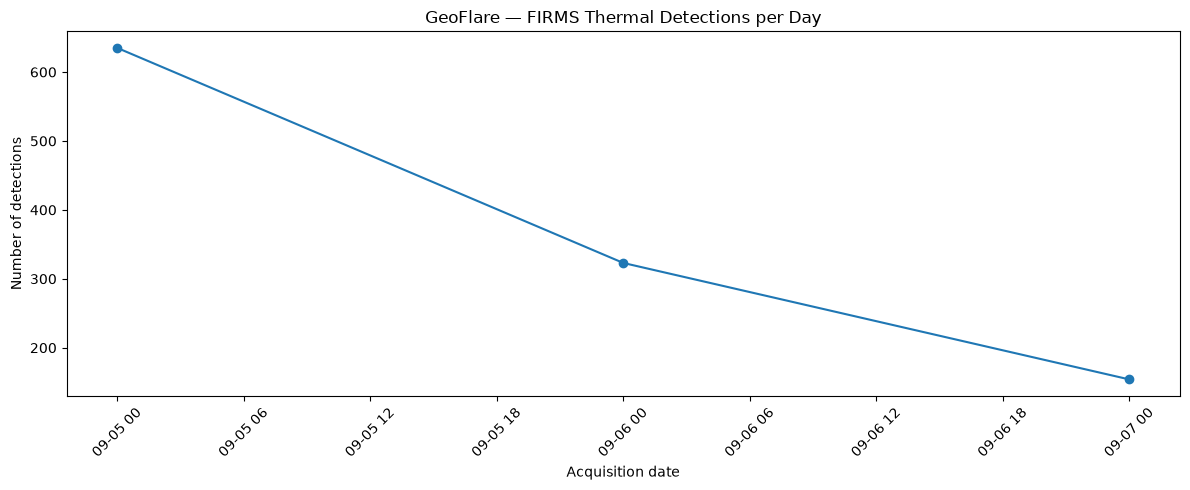

In [28]:
if "acq_date" in fires.columns:
    daily_counts = fires.groupby("acq_date").size()
    plt.figure(figsize=(12,5))
    plt.plot(daily_counts.index, daily_counts.values, marker="o")
    plt.title("GeoFlare — FIRMS Thermal Detections per Day")
    plt.xlabel("Acquisition date")
    plt.ylabel("Number of detections")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 6. FRP distribution

> **High FRP does not automatically mean industrial fire.**

That is why GeoFlare combines thermal information with **history + persistence + OSM context**.

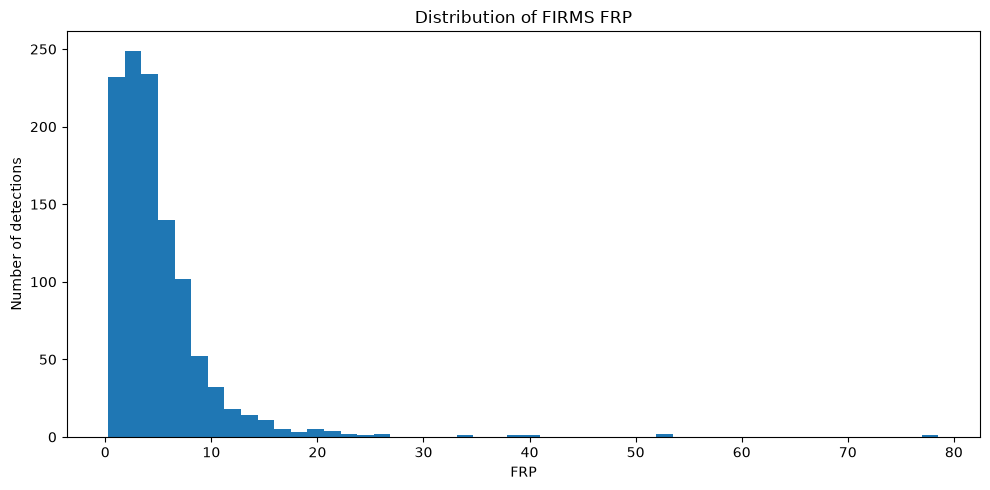

In [29]:
if "frp" in fires.columns:
    plt.figure(figsize=(10,5))
    plt.hist(fires["frp"].dropna(), bins=50)
    plt.title("Distribution of FIRMS FRP")
    plt.xlabel("FRP")
    plt.ylabel("Number of detections")
    plt.tight_layout()
    plt.show()

In [30]:
if "frp" in fires.columns:
    top_frp = fires.sort_values("frp", ascending=False).head(20)
    useful = [c for c in [
        "latitude","longitude","acq_datetime","frp","confidence",
        "bright_ti4","satellite","instrument","daynight"
    ] if c in top_frp.columns]
    display(top_frp[useful])

,latitude,longitude,acq_datetime,frp,confidence,bright_ti4,satellite,instrument,daynight
973,6.78047,81.21812,2026-09-07 07:35:00,78.55,n,342.93,N,VIIRS,D
972,6.77853,81.20697,2026-09-07 07:35:00,53.26,n,332.31,N,VIIRS,D
971,6.77457,81.21329,2026-09-07 07:35:00,53.26,n,349.58,N,VIIRS,D
734,8.56460,80.74776,2026-09-06 07:56:00,40.67,l,343.58,N,VIIRS,D
119,7.94364,81.34592,2026-09-05 08:13:00,38.02,n,347.98,N,VIIRS,D
271,8.69685,81.02242,2026-09-05 08:13:00,34.68,n,341.25,N,VIIRS,D
384,14.77525,79.79544,2026-09-05 08:16:00,25.68,n,353.09,N,VIIRS,D
959,6.32406,81.31542,2026-09-07 07:35:00,25.64,n,340.99,N,VIIRS,D
726,8.50974,80.18266,2026-09-06 07:56:00,23.97,l,335.74,N,VIIRS,D
262,8.67411,80.84435,2026-09-05 08:13:00,22.92,n,337.37,N,VIIRS,D


## 7. Day vs night

Temporal behavior may become a useful feature later.

This is **not** a classification rule by itself.

,detections
daynight,
D,762
N,350


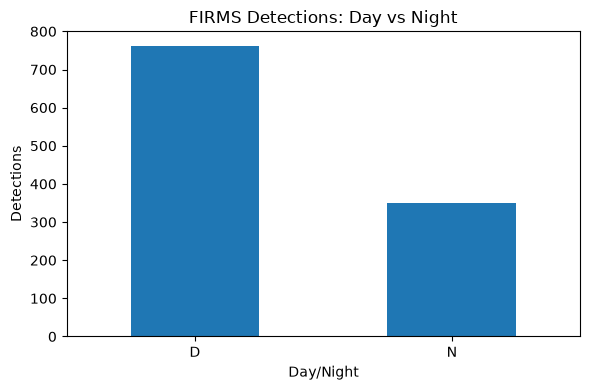

In [31]:
if "daynight" in fires.columns:
    counts = fires["daynight"].value_counts(dropna=False)
    display(counts.to_frame("detections"))

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar")
    plt.title("FIRMS Detections: Day vs Night")
    plt.xlabel("Day/Night")
    plt.ylabel("Detections")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 8. First geographic visualization

For now we use a simple longitude/latitude scatter plot.

Later we will add proper geospatial layers using GeoPandas, OpenStreetMap and eventually PostGIS.

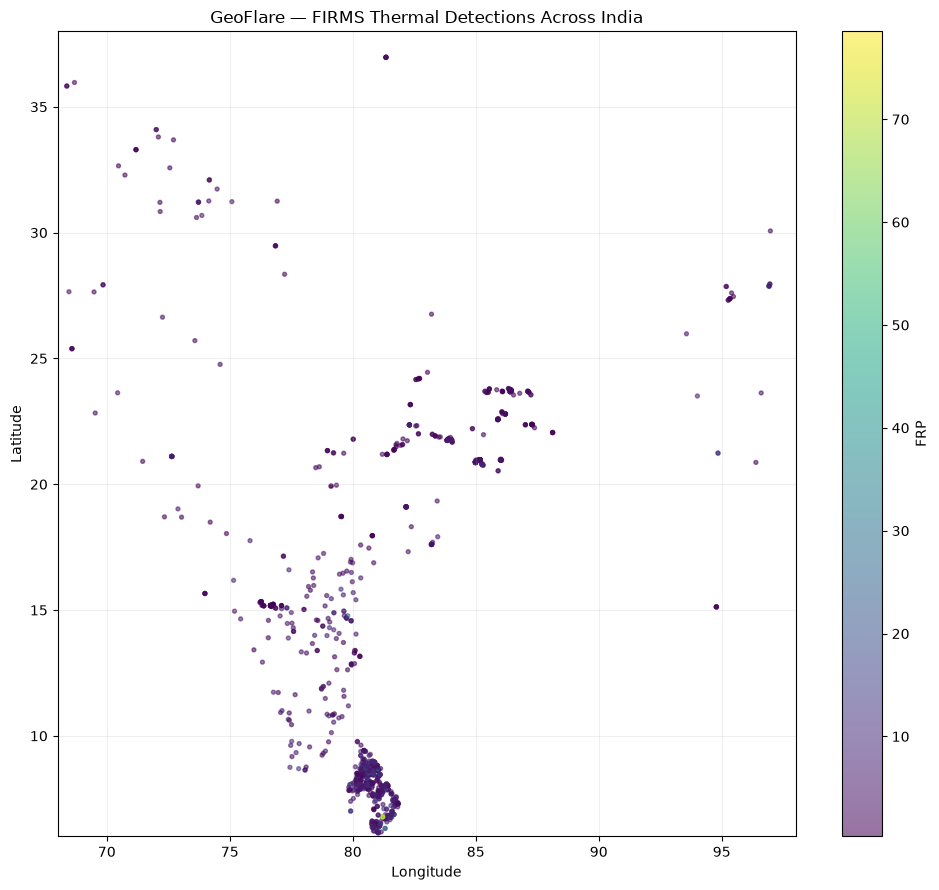

In [ ]:
if {"latitude","longitude"}.issubset(fires.columns):
    plt.figure(figsize=(10,9))
    scatter = plt.scatter(
        fires["longitude"], fires["latitude"],
        c=fires["frp"] if "frp" in fires.columns else None,
        s=8, alpha=0.55
    )
    plt.xlim(68, 98)
    plt.ylim(6, 38)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("ThermoTech — FIRMS Thermal Detections Across India")

    if "frp" in fires.columns:
        plt.colorbar(scatter, label="FRP")

    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## 9. Look for spatial concentration

The next question is:

**Do detections repeatedly occur around the same locations?**

That is the beginning of our historical-baseline idea.

In [33]:
if {"latitude","longitude"}.issubset(fires.columns):
    spatial = fires.copy()
    spatial["lat_grid"] = spatial["latitude"].round(2)
    spatial["lon_grid"] = spatial["longitude"].round(2)

    hotspot_cells = (
        spatial.groupby(["lat_grid","lon_grid"])
        .size()
        .reset_index(name="detection_count")
        .sort_values("detection_count", ascending=False)
        .head(20)
    )

    display(hotspot_cells)

,lat_grid,lon_grid,detection_count
646,20.97,86.01,8
626,20.86,84.99,8
611,19.10,82.17,7
547,15.18,76.67,7
546,15.18,76.66,7
642,20.97,85.17,6
677,21.75,83.84,6
702,22.36,82.30,6
709,22.57,85.90,6
707,22.38,87.28,6


## 10. Save the cleaned dataset

This becomes the input for:

**Notebook 02 → Historical Baseline & Persistence**

We will add:
- persistence duration,
- detection frequency,
- historical mean FRP,
- FRP variability,
- anomaly scores,
- recurring vs one-off behavior.

In [34]:
processed_file = PROCESSED_DIR / "firms_india_clean.csv"
fires.to_csv(processed_file, index=False)

print(f"Saved: {processed_file}")
print("Rows:", len(fires))
print("Columns:", len(fires.columns))

Saved: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\processed\firms_india_clean.csv
Rows: 1112
Columns: 16


# 11. Phase 1 checkpoint ✅

Before moving on, confirm:

- [ ] Real FIRMS data downloaded
- [ ] Row/column counts checked
- [ ] Missing values checked
- [ ] Coordinates validated
- [ ] FRP distribution inspected
- [ ] Daily detections plotted
- [ ] Highest-FRP detections inspected
- [ ] India map created
- [ ] Repeated spatial cells inspected
- [ ] Clean CSV saved

### Next notebook

`02_baseline.ipynb`

Core idea:

**HOTSPOT ≠ FIRE**

A single thermal detection is only a hotspot.

Repeated detections at the same location can indicate a **persistent thermal source**.

A sudden abnormal increase can indicate a possible **industrial fire event**.